In [2]:
# ATMS 523 Weather and Climate Data Analytics
# Project 2: dask & xarray for computing weather and climate diagnostics
# ERA-5 Precipitation Analysis
# Zachary R. Torstrick

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from dask.distributed import Client

# Set up dask client for parallel processing
client = Client()
print(f"Dask dashboard: {client.dashboard_link}")
client

/opt/conda/envs/xarray-climate/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34633 instead
  warnings.warn(


Dask dashboard: http://127.0.0.1:34633/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:34633/status,
Dashboard: http://127.0.0.1:34633/status,Workers: 4
Total threads: 4,Total memory: 16.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45841,Workers: 0
Dashboard: http://127.0.0.1:34633/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40287,Total threads: 1
Dashboard: http://127.0.0.1:40893/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:46773,


In [3]:
# Load the ERA-5 dataset from Google Cloud Platform ARCO
# This dataset contains hourly ERA-5 reanalysis data on a 0.25-degree grid

ds = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3',
    chunks=None,
    storage_options=dict(token='anon'),
)

# Filter to a specific time period for analysis
ds = ds.sel(time=slice(ds.attrs['valid_time_start'], ds.attrs['valid_time_stop']))

ds


<xarray.Dataset> Size: 2PB
Dimensions:                                                          (
                                                                      time: 748008,
                                                                      latitude: 721,
                                                                      longitude: 1440,
                                                                      level: 37)
Coordinates:
  * latitude                                                         (latitude) float32 3kB ...
  * level                                                            (level) int64 296B ...
  * longitude                                                        (longitude) float32 6kB ...
  * time                                                             (time) datetime64[ns] 6MB ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, latitude, longitude) float32 3TB ...
    100m_v_component_of_wind                                         (time, latitude, longitude) float32 3TB ...
    10m_u_component_of_neutral_wind                                  (time, latitude, longitude) float32 3TB ...
    10m_u_component_of_wind                                          (time, latitude, longitude) float32 3TB ...
    10m_v_component_of_neutral_wind                                  (time, latitude, longitude) float32 3TB ...
    10m_v_component_of_wind                                          (time, latitude, longitude) float32 3TB ...
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, latitude, longitude) float32 3TB ...
    wave_spectral_directional_width_for_wind_waves                   (time, latitude, longitude) float32 3TB ...
    wave_spectral_kurtosis                                           (time, latitude, longitude) float32 3TB ...
    wave_spectral_peakedness                                         (time, latitude, longitude) float32 3TB ...
    wave_spectral_skewness                                           (time, latitude, longitude) float32 3TB ...
    zero_degree_level                                                (time, latitude, longitude) float32 3TB ...
Attributes:
    last_updated:           2025-10-03 02:04:12.135854+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-04-30
    valid_time_stop_era5t:  2025-09-27

In [4]:
# Explore the dataset to find precipitation variables
precip_columns = [var for var in ds.data_vars.keys() if "precip" in var.lower()]
print("\n".join(precip_columns))

convective_precipitation
instantaneous_large_scale_surface_precipitation_fraction
large_scale_precipitation
large_scale_precipitation_fraction
maximum_total_precipitation_rate_since_previous_post_processing
mean_convective_precipitation_rate
mean_large_scale_precipitation_fraction
mean_large_scale_precipitation_rate
mean_total_precipitation_rate
minimum_total_precipitation_rate_since_previous_post_processing
precipitation_type
total_precipitation


per lab instructions, we care about total precipitation

(1) Use the precipitation output of ERA-5 to compute a time series of daily precipitation at a given point closest to a city of your choosing. Choose a box of 5 x 5 deg lat-lon values over the grid box closest to the city you are examining.  Save this data.  Use a period of at least 10 years.

In [5]:
# Seattle coordinates according to Google search
seattle_lat = 47.6061  # degrees North
seattle_lon = -122.3328  # degrees West

# Convert to 0-360°
seattle_lon = 360 + seattle_lon

# A 5x5 degree grid extends 2.5 degrees in each direction from Seattle
lat_min = seattle_lat - 2.5  # 45.1061°N
lat_max = seattle_lat + 2.5  # 50.1061°N
lon_min = seattle_lon - 2.5  # 235.1672°
lon_max = seattle_lon + 2.5  # 240.1672°

print(f"Analysis box bounds:")
print(f"  Latitude: {lat_min:.4f}° to {lat_max:.4f}°")
print(f"  Longitude: {lon_min:.4f}° to {lon_max:.4f}°")

# Filter the dataset to our analysis box around Seattle
ds_seattle = ds.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
print(f"\nSeattle region dataset shape: {ds_seattle.dims}")

Analysis box bounds:
  Latitude: 45.1061° to 50.1061°
  Longitude: 235.1672° to 240.1672°

Seattle region dataset shape: FrozenMappingWarningOnValuesAccess({'time': 748008, 'latitude': 0, 'longitude': 20, 'level': 37})


Something went wrong. We got not latitude values. Let's see if latitude is in DESC or ASC.

In [6]:
# Check if latitude coordinates are in ascending or descending order
print(f"\nBegin: {ds.latitude[:1].values}")
print(f"End: {ds.latitude[-1:].values}")


Begin: [90.]
End: [-90.]


Latitude is DESC, so we need to slice backwards.

In [7]:
# Filter with lat bounds reversed
ds_seattle = ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))
print(f"\nSeattle region dataset shape: {ds_seattle.dims}")


Seattle region dataset shape: FrozenMappingWarningOnValuesAccess({'time': 748008, 'latitude': 20, 'longitude': 20, 'level': 37})


In [8]:
# Extract and save precipitation data for Seattle region (1991-2020)

import os

filename = 'seattle_precipitation_5x5deg_1991_2020.nc'
if os.path.exists(filename):
    print(f"✓ Found existing file: {filename}")    
    precip_seattle = xr.open_dataset(filename)['total_precipitation']
    
else:
    # Save precipitation data for Seattle region (1991-2020)
    # as NetCDF (preserves all metadata and xarray structure)
    print("File not found locally. Extracting from cloud dataset...")
    precip_seattle = ds_seattle['total_precipitation'].sel(time=slice('1991-01-01', '2020-12-31'))
    precip_seattle.to_netcdf('seattle_precipitation_5x5deg_1991_2020.nc')

✓ Found existing file: seattle_precipitation_5x5deg_1991_2020.nc


(2) Determine the 95% values of daily precipitation for the data created in (1).  Plot a *cumulative distribution function* of all values daily precipitation values and illustrate the 95% value of daily precipitation in millimeters.

5% of the time, the daily precipitation in the Seattle region exceeds 18.17 mm


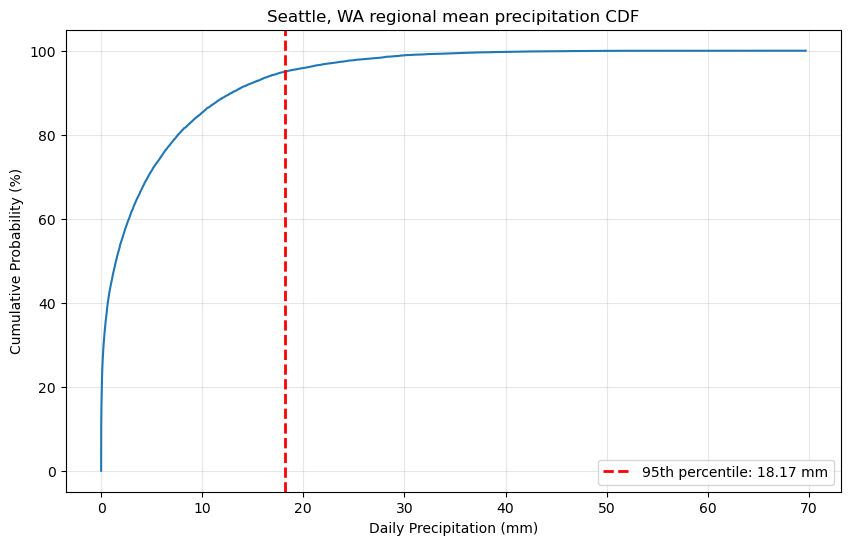

In [9]:
# Convert hourly to daily precipitation totals
daily_precip = precip_seattle.resample(time='1D').sum()

# Convert from meters to millimeters
daily_precip = daily_precip * 1000

# Compute spatial average for each day
mean_regional_precip = daily_precip.mean(dim=['latitude','longitude'])

# Find 95th percentile of daily spatial averages
p95_threshold = mean_regional_precip.quantile(0.95, dim='time')

print(f'5% of the time, the daily precipitation in the Seattle region exceeds {p95_threshold.values:.2f} mm')

# Create CDF of the 95th percentile values
sorted_precip = np.sort(mean_regional_precip)
n = len(sorted_precip)
cdf_probs = np.arange(1, n+1) / n * 100

# Plot CDF
plt.figure(figsize=(10, 6))
plt.plot(sorted_precip, cdf_probs)
plt.axvline(x=p95_threshold.values, color='red', linestyle='--', linewidth=2, 
           label=f'95th percentile: {p95_threshold.values:.2f} mm')
plt.xlabel('Daily Precipitation (mm)')
plt.ylabel('Cumulative Probability (%)')
plt.grid(True, alpha=0.3)
plt.title('Seattle, WA regional mean precipitation CDF')
plt.legend()
plt.show()

# Identify extreme days (top 5% of days)
extreme_days = mean_regional_precip >= p95_threshold

This is a CDF of the average precipitation over the 5°X5° box surrrounding Seattle. This may be a problematic region due to its diverse geography.

(3) Create a map of the composite mean precipitation on the 95% days identified in (2) over the continental USA, and a map of the anomaly of precipitation from the 1981-2010 mean. This field should be plotted on a Cartopy map centered at your city with a 40 x 40 degree lat-lon range.

First pull USA data

In [10]:
# Continental USA approximate bounds
usa_lat_min = 24.0   # Southern border (Florida Keys)
usa_lat_max = 49.0   # Northern border (Canada border)
usa_lon_min = -125.0  # Western border (Pacific coast)
usa_lon_max = -66.0   # Eastern border (Atlantic coast)

# Convert longitude to 0-360° format
usa_lon_min_360 = 360 + usa_lon_min  # 235.0°
usa_lon_max_360 = 360 + usa_lon_max  # 294.0°

# Filter the dataset to USA bounds
ds_usa = ds.sel(
    latitude=slice(usa_lat_max, usa_lat_min),  # Note: reversed for descending lat
    longitude=slice(usa_lon_min_360, usa_lon_max_360)
)

# Extract and save precipitation data for USA (1991-2020)
filename = 'usa_precipitation_extreme_days_1991_2020.nc'
if os.path.exists(filename):
    print(f"✓ Found existing file: {filename}")    
    precip_usa_extreme = xr.open_dataset(filename)['total_precipitation']
else:
    # Save precipitation data for USA - ONLY on extreme days
    # as NetCDF (preserves all metadata and xarray structure)
    print("File not found locally. Extracting from cloud dataset...")
    print("This will only extract data for extreme days to save space and time...")
    
    # First get the full USA dataset for the time period
    precip_usa_full = ds_usa['total_precipitation'].sel(time=slice('1991-01-01', '2020-12-31'))
    
    # Convert to daily and select only extreme days
    precip_usa_daily = precip_usa_full.resample(time='1D').sum() * 1000  # Convert to mm
    precip_usa_extreme = precip_usa_daily.sel(time=extreme_dates)



✓ Found existing file: usa_precipitation_extreme_days_1991_2020.nc


Now plot the composite mean

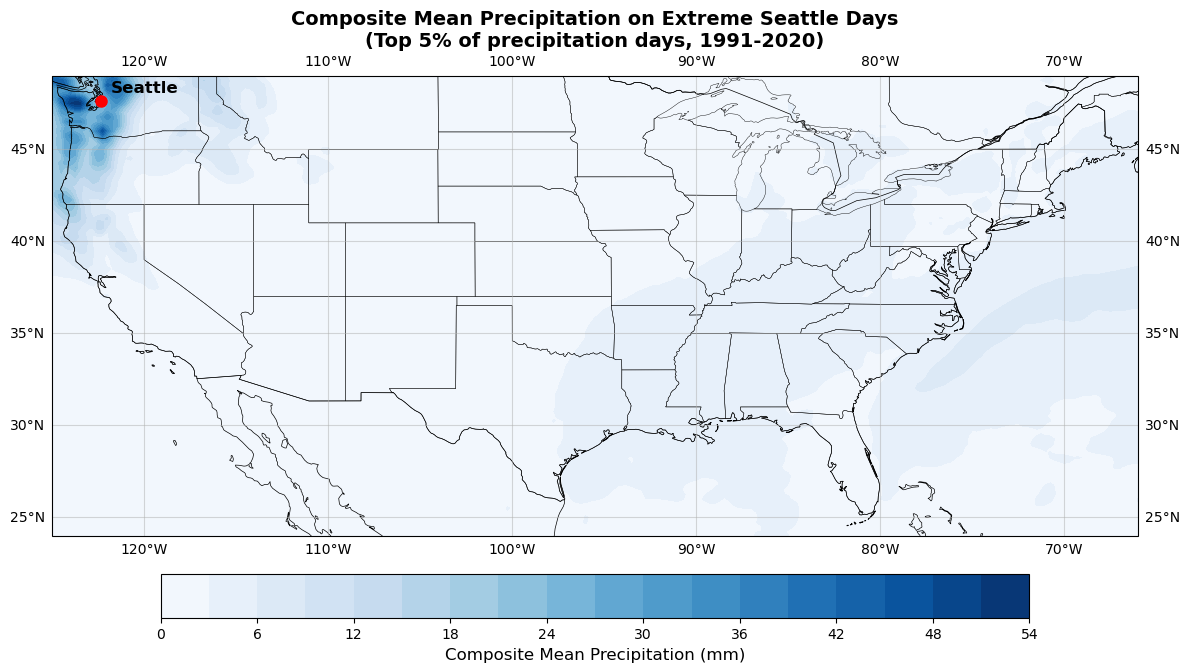

In [11]:
# Composite mean precipitation (average across all extreme days)
composite_mean_precip = precip_usa_extreme.mean(dim='time')

# Create the composite mean precipitation map
fig = plt.figure(figsize=(12, 8))

# Create map with USA bounds as defined earlier
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([usa_lon_min, usa_lon_max, usa_lat_min, usa_lat_max], 
               crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)
ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.3)

# Plot the composite mean precipitation
# Convert longitude from 0-360 to -180 to 180 for cartopy
lon_plot = composite_mean_precip.longitude.values
lon_plot[lon_plot > 180] = lon_plot[lon_plot > 180] - 360
lon_mesh, lat_mesh = np.meshgrid(lon_plot, composite_mean_precip.latitude.values)

# Plot the precipitation data
im = ax.contourf(lon_mesh, lat_mesh, composite_mean_precip.values, 
                levels=20, cmap='Blues', transform=ccrs.PlateCarree())

# Add colorbar
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label('Composite Mean Precipitation (mm)', fontsize=12)

# Mark Seattle location
ax.plot(seattle_lon, seattle_lat, 'ro', markersize=8, transform=ccrs.PlateCarree())
ax.text(seattle_lon+0.5, seattle_lat+0.5, 'Seattle', transform=ccrs.PlateCarree(), 
        fontsize=12, fontweight='bold')

# Add gridlines
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.5)

# Set title
plt.title('Composite Mean Precipitation on Extreme Seattle Days\n(Top 5% of precipitation days, 1991-2020)', 
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Computing the mean across the USA proved difficult, so using the monthly file provided by S. Nesbitt

In [ ]:
# Load the ERA5 monthly precipitation data file
era5_filename = 'ERA-5_total_precipitation_monthly-1981-2020.nc'
if os.path.exists(era5_filename):
    print(f"✓ Found existing file: {era5_filename}")    
    monthly_precip = xr.open_dataset(era5_filename)['tp']
else:
    monthly_precip = xr.open_dataset(
        'https://www.atmos.illinois.edu/~snesbitt/data/ERA-5_total_precipitation_monthly-1981-2020.nc', 
        engine='h5netcdf')
    monthly_precip.to_netcdf(era5_filename)
    
# Filter clim_mean to USA bounds
monthly_precip_usa = monthly_precip.sel(
    latitude=slice(49.0, 24.0),  # Note: reversed for descending lat
    longitude=slice(235.0, 294.0)  # 0-360° format
)

# Adjust longitude
monthly_precip_usa = monthly_precip_usa.assign_coords(
    longitude=monthly_precip_usa.longitude.where(
        monthly_precip_usa.longitude <= 180, monthly_precip_usa.longitude - 360)
        )

clim_mean_usa = monthly_precip_usa.mean(dim='valid_time')
anomaly = composite_mean_precip - clim_mean_usa

✓ Found existing file: ERA-5_total_precipitation_monthly-1981-2020.nc


Now map anomalies

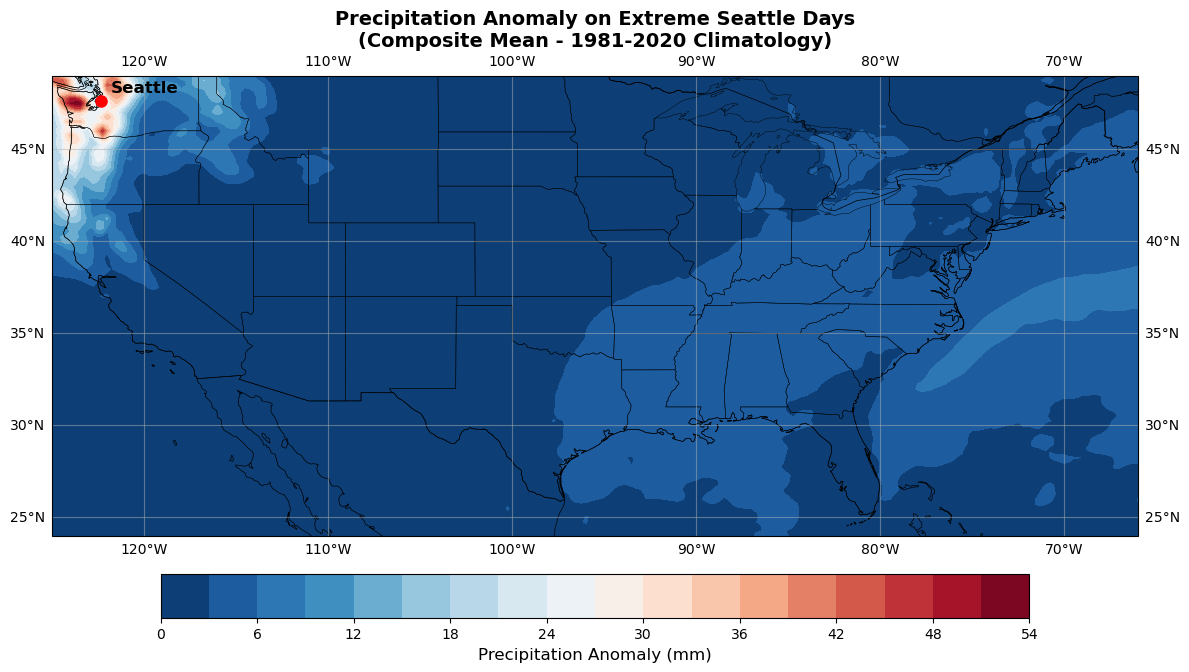

In [15]:
# Create the anomaly map
fig = plt.figure(figsize=(12, 8))

# Create map with USA bounds as defined earlier
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([usa_lon_min, usa_lon_max, usa_lat_min, usa_lat_max], 
               crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)
ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.3)

# Plot the anomaly data
# Convert longitude from 0-360 to -180 to 180 for plotting
lon_plot_anom = anomaly.longitude.values
lon_plot_anom[lon_plot_anom > 180] = lon_plot_anom[lon_plot_anom > 180] - 360
lon_mesh_anom, lat_mesh_anom = np.meshgrid(lon_plot_anom, anomaly.latitude.values)

# Plot the anomaly data with diverging colormap
im_anom = ax.contourf(lon_mesh_anom, lat_mesh_anom, anomaly.values, 
                     levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())

# Add colorbar
cbar_anom = plt.colorbar(im_anom, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar_anom.set_label('Precipitation Anomaly (mm)', fontsize=12)

# Mark Seattle location
ax.plot(seattle_lon, seattle_lat, 'ro', markersize=8, transform=ccrs.PlateCarree())
ax.text(seattle_lon+0.5, seattle_lat+0.5, 'Seattle', transform=ccrs.PlateCarree(), 
        fontsize=12, fontweight='bold')

# Add gridlines
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.5)

# Set title
plt.title('Precipitation Anomaly on Extreme Seattle Days\n(Composite Mean - 1981-2020 Climatology)', 
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
